# CCS3356 – Sentiment Analysis of Customer Reviews
## Member 03 – A S M Aasim (CIT-24-01-0298)
**ML Model:** Naive Bayes
**DL Model:** RNN (SimpleRNN) for Text Classification

**Pipeline:** Dataset Exploration → Text Cleaning → Tokenization → Lemmatization → Word Embedding → Model Training → Evaluation → Visualization


In [1]:
import sys, re, time
sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from data_utils import load_dataset, get_split, RANDOM_STATE

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              precision_recall_fscore_support)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

sns.set_style('whitegrid')
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


I0000 00:00:1786825413.120612    1224 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786825413.168676    1224 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786825414.589867    1224 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 1. Dataset Exploration
Analyzing the dataset's size, structure, class distribution, and data quality before
preprocessing and modeling.

In [2]:
df = load_dataset('../data/1429_1.csv')
print('Shape:', df.shape)
print('\nMissing values per column:')
print(df.isna().sum())
print('\nRating distribution:')
print(df['rating'].value_counts().sort_index())
df.head()


Shape: (34626, 6)

Missing values per column:
id                 0
name            6759
rating             0
review_text        0
review_title       6
sentiment          0
dtype: int64

Rating distribution:
rating
1.0      410
2.0      402
3.0     1499
4.0     8541
5.0    23774
Name: count, dtype: int64


/home/claude/NLP-Sentiment-Analysis-Group12/notebooks/../src/data_utils.py:46: DtypeWarning: Columns (0: name, 1: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,id,name,rating,review_text,review_title,sentiment
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,This product so far has not disappointed. My c...,Kindle,Positive
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,great for beginner or experienced person. Boug...,very fast,Positive
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,Positive
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,Positive
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,Positive


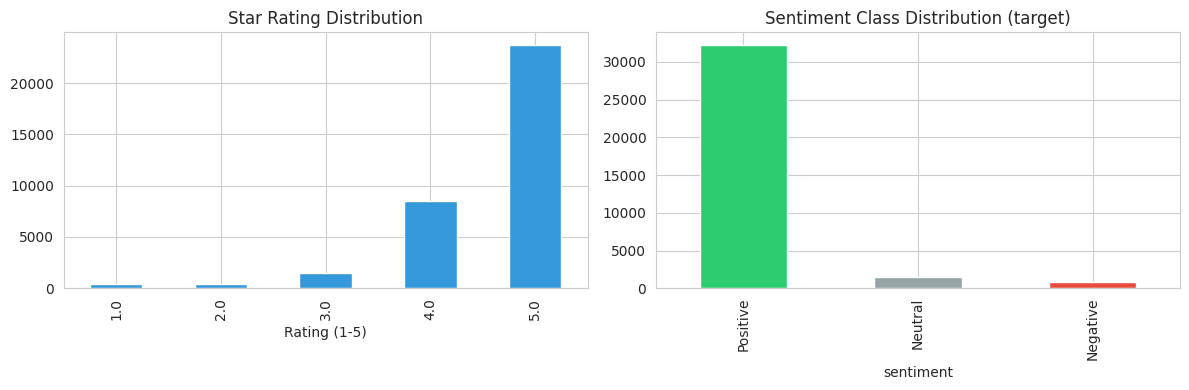

sentiment
Positive    0.933
Neutral     0.043
Negative    0.023
Name: proportion, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#3498db')
axes[0].set_title('Star Rating Distribution')
axes[0].set_xlabel('Rating (1-5)')

df['sentiment'].value_counts().plot(kind='bar', ax=axes[1], color=['#2ecc71','#95a5a6','#e74c3c'])
axes[1].set_title('Sentiment Class Distribution (target)')
plt.tight_layout()
plt.show()
print(df['sentiment'].value_counts(normalize=True).round(3))


**Insight:** Ratings are heavily skewed towards 4-5 stars, so the mapped Positive class
dominates the dataset (~93%). This class imbalance — flagged in Section 6 of the project
validation submission — is addressed below with `class_weight='balanced'` during model
training and by reporting macro-averaged metrics (not just accuracy).

## 2. Text Cleaning
Removing special characters, punctuation, URLs, numbers, and extra spaces.

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['review_text'].apply(clean_text)
df[['review_text','clean_text']].head(3)


,review_text,clean_text
0,This product so far has not disappointed. My c...,this product so far has not disappointed my ch...
1,great for beginner or experienced person. Boug...,great for beginner or experienced person bough...
2,Inexpensive tablet for him to use and learn on...,inexpensive tablet for him to use and learn on...


## 3. Tokenization & Lemmatization

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def tokenize_lemmatize(text):
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words and len(tok) > 2]
    return tokens

t0 = time.time()
df['tokens'] = df['clean_text'].apply(tokenize_lemmatize)
df['processed_text'] = df['tokens'].apply(lambda toks: ' '.join(toks))
print(f'Preprocessing done in {time.time()-t0:.1f}s')
df[['processed_text']].head(3)


Preprocessing done in 4.9s


,processed_text
0,product far disappointed child love use like a...
1,great beginner experienced person bought gift ...
2,inexpensive tablet use learn step nabi thrille...


## 4. Word Frequency Analysis & Visualization (EDA)

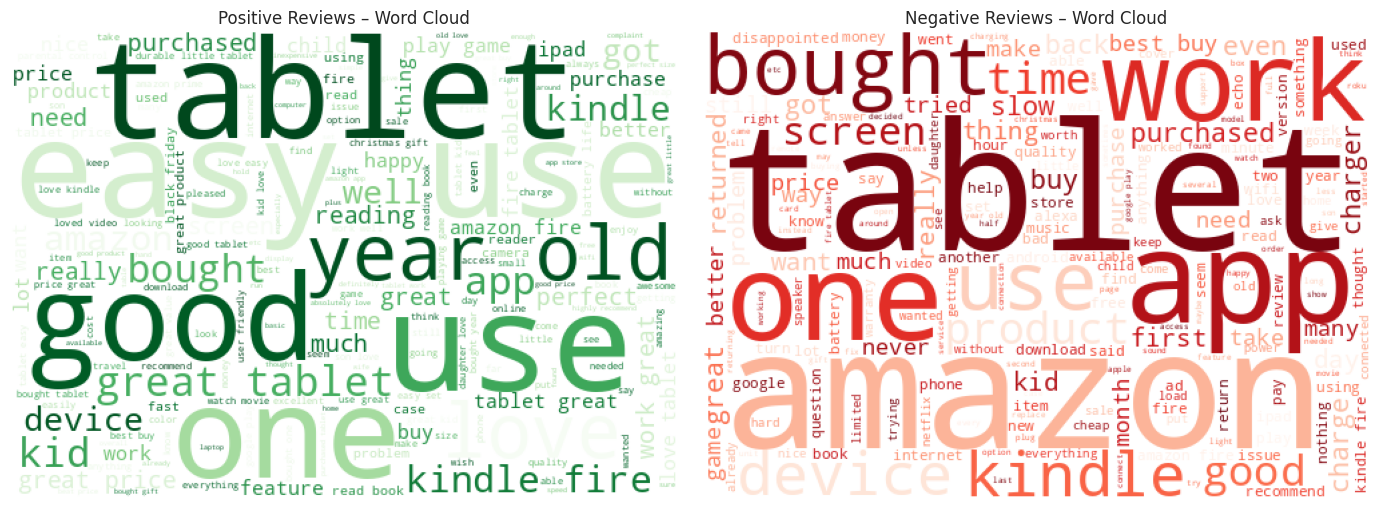

In [6]:
from collections import Counter

pos_words = [w for toks in df.loc[df.sentiment=='Positive','tokens'] for w in toks]
neg_words = [w for toks in df.loc[df.sentiment=='Negative','tokens'] for w in toks]

fig, axes = plt.subplots(1, 2, figsize=(14,5))
WordCloud(width=500, height=350, background_color='white', colormap='Greens').generate(' '.join(pos_words[:200000])).to_image()
axes[0].imshow(WordCloud(width=500, height=350, background_color='white', colormap='Greens').generate(' '.join(pos_words[:200000])))
axes[0].axis('off'); axes[0].set_title('Positive Reviews – Word Cloud')

axes[1].imshow(WordCloud(width=500, height=350, background_color='white', colormap='Reds').generate(' '.join(neg_words[:200000])))
axes[1].axis('off'); axes[1].set_title('Negative Reviews – Word Cloud')
plt.tight_layout()
plt.show()


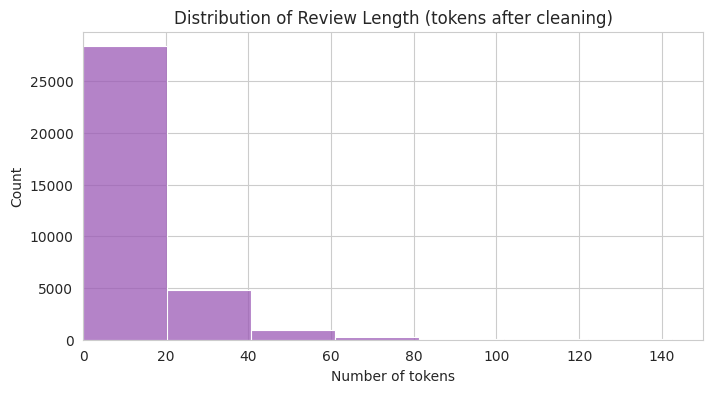

count    34626.000000
mean        14.688067
std         16.362087
min          0.000000
25%          7.000000
50%         10.000000
75%         17.000000
max       1017.000000
Name: tokens, dtype: float64


In [7]:
review_lengths = df['tokens'].apply(len)
plt.figure(figsize=(8,4))
sns.histplot(review_lengths, bins=50, color='#9b59b6')
plt.title('Distribution of Review Length (tokens after cleaning)')
plt.xlabel('Number of tokens')
plt.xlim(0, 150)
plt.show()
print(review_lengths.describe())


## 5. Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = get_split(df, text_col='processed_text', label_col='sentiment')
print(X_train.shape, X_test.shape)


(27700,) (6926,)


## 6. ML Model – Naive Bayes
Naive Bayes is computationally efficient, simple to implement, and widely used as a
baseline model for text classification tasks. TF-IDF features are used since
`MultinomialNB` requires non-negative count-like features.

In [9]:
tfidf = TfidfVectorizer(max_features=8000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

nb_model = MultinomialNB()
t0 = time.time()
nb_model.fit(X_train_tfidf, y_train)
print(f'Naive Bayes trained in {time.time()-t0:.1f}s')


Naive Bayes trained in 0.0s


Accuracy: 0.9332948310713255
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       162
     Neutral       0.00      0.00      0.00       300
    Positive       0.93      1.00      0.97      6464

    accuracy                           0.93      6926
   macro avg       0.31      0.33      0.32      6926
weighted avg       0.87      0.93      0.90      6926



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


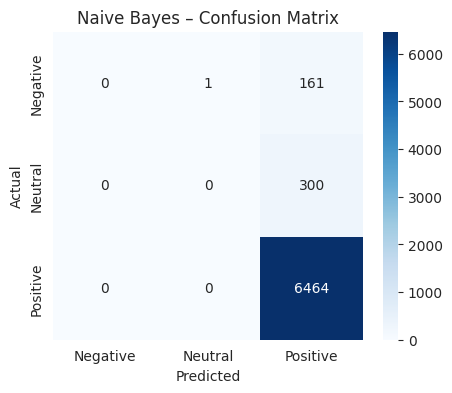

In [10]:
y_pred_nb = nb_model.predict(X_test_tfidf)
print('Accuracy:', accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

cm = confusion_matrix(y_test, y_pred_nb, labels=['Negative','Neutral','Positive'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title('Naive Bayes – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()


**Note:** Plain Naive Bayes (no class balancing) tends to collapse toward the majority
Positive class on this imbalanced dataset. A `sample_weight`-balanced variant is
trained below for a fairer comparison against the other members' balanced models.

In [11]:
from sklearn.utils.class_weight import compute_sample_weight
sw = compute_sample_weight('balanced', y_train)
nb_balanced = MultinomialNB()
nb_balanced.fit(X_train_tfidf, y_train, sample_weight=sw)
y_pred_nb_bal = nb_balanced.predict(X_test_tfidf)
print('Balanced NB Accuracy:', accuracy_score(y_test, y_pred_nb_bal))
print(classification_report(y_test, y_pred_nb_bal))


Balanced NB Accuracy: 0.7698527288478199
              precision    recall  f1-score   support

    Negative       0.16      0.60      0.25       162
     Neutral       0.13      0.49      0.21       300
    Positive       0.98      0.79      0.87      6464

    accuracy                           0.77      6926
   macro avg       0.42      0.63      0.44      6926
weighted avg       0.93      0.77      0.83      6926



## 7. Word Embedding + DL Model – SimpleRNN
Word embeddings convert text into dense numerical vectors that capture semantic and
contextual relationships between words, learned here inside the network's `Embedding`
layer. RNNs can identify important local sequential patterns and phrases in text.

In [12]:
MAX_WORDS = 10000
MAX_LEN = 100

label_map = {'Negative':0, 'Neutral':1, 'Positive':2}
inv_label_map = {v:k for k,v in label_map.items()}
y_train_int = y_train.map(label_map).values
y_test_int = y_test.map(label_map).values
y_train_cat = to_categorical(y_train_int, num_classes=3)
y_test_cat = to_categorical(y_test_int, num_classes=3)

keras_tok = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
keras_tok.fit_on_texts(X_train)
X_train_seq = pad_sequences(keras_tok.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq = pad_sequences(keras_tok.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post', truncating='post')
print(X_train_seq.shape, X_test_seq.shape)


(27700, 100) (6926, 100)


In [13]:
rnn_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])
rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_train_int)
# Dampen extreme weights (sqrt) so gradient-based training doesn't over-correct
cw = np.sqrt(cw)
class_weight_dict = {i: w for i, w in enumerate(cw)}

history = rnn_model.fit(
    X_train_seq, y_train_cat,
    validation_split=0.1,
    epochs=4, batch_size=128,
    class_weight=class_weight_dict,
    verbose=2
)


Epoch 1/4


195/195 - 9s - 49ms/step - accuracy: 0.9067 - loss: 0.6388 - val_accuracy: 0.9357 - val_loss: 0.4733


Epoch 2/4


195/195 - 10s - 51ms/step - accuracy: 0.9326 - loss: 0.6149 - val_accuracy: 0.9357 - val_loss: 0.4368


Epoch 3/4


195/195 - 10s - 53ms/step - accuracy: 0.9329 - loss: 0.6098 - val_accuracy: 0.9357 - val_loss: 0.4615


Epoch 4/4


195/195 - 10s - 52ms/step - accuracy: 0.9330 - loss: 0.6037 - val_accuracy: 0.9357 - val_loss: 0.4748


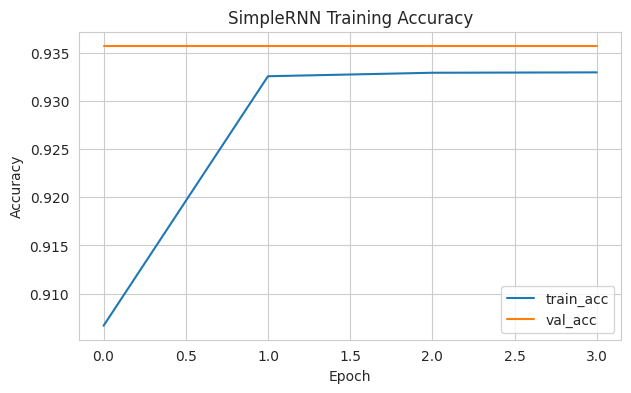

In [15]:
plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('SimpleRNN Training Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()
plt.show()


Accuracy: 0.9332948310713255
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00       162
     Neutral       0.00      0.00      0.00       300
    Positive       0.93      1.00      0.97      6464

    accuracy                           0.93      6926
   macro avg       0.31      0.33      0.32      6926
weighted avg       0.87      0.93      0.90      6926



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


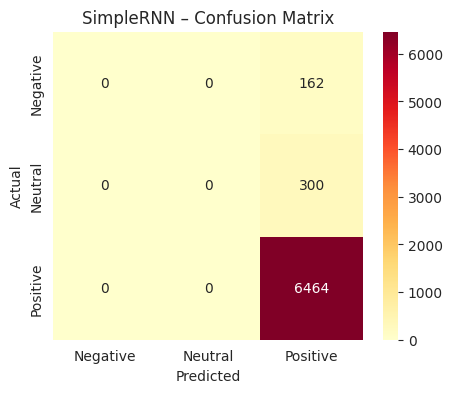

In [16]:
y_pred_rnn_prob = rnn_model.predict(X_test_seq, verbose=0)
y_pred_rnn = np.argmax(y_pred_rnn_prob, axis=1)
y_pred_rnn_labels = [inv_label_map[i] for i in y_pred_rnn]

print('Accuracy:', accuracy_score(y_test, y_pred_rnn_labels))
print(classification_report(y_test, y_pred_rnn_labels))

cm2 = confusion_matrix(y_test, y_pred_rnn_labels, labels=['Negative','Neutral','Positive'])
plt.figure(figsize=(5,4))
sns.heatmap(cm2, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])
plt.title('SimpleRNN – Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()


## 8. Model Comparison – Naive Bayes (balanced) vs SimpleRNN

In [17]:
def macro_scores(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return accuracy_score(y_true, y_pred), p, r, f1

acc_nb, p_nb, r_nb, f1_nb = macro_scores(y_test, y_pred_nb_bal)
acc_rnn, p_rnn, r_rnn, f1_rnn = macro_scores(y_test, y_pred_rnn_labels)

comparison = pd.DataFrame({
    'Model': ['Naive Bayes (ML, balanced)', 'SimpleRNN (DL)'],
    'Accuracy': [acc_nb, acc_rnn],
    'Macro Precision': [p_nb, p_rnn],
    'Macro Recall': [r_nb, r_rnn],
    'Macro F1': [f1_nb, f1_rnn],
})
comparison


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,"Naive Bayes (ML, balanced)",0.769853,0.423474,0.626358,0.443287
1,SimpleRNN (DL),0.933295,0.311098,0.333333,0.321832


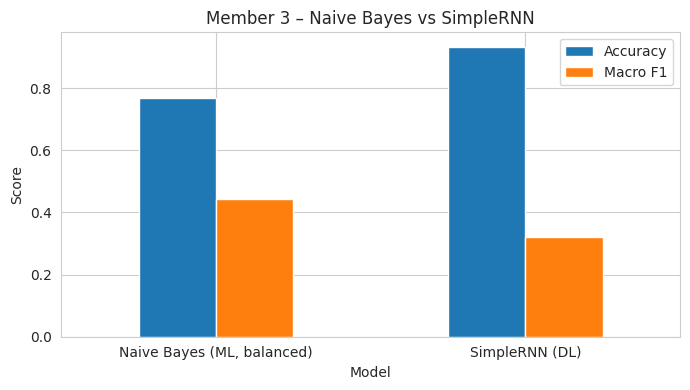

In [18]:
comparison.set_index('Model')[['Accuracy','Macro F1']].plot(kind='bar', figsize=(7,4))
plt.title('Member 3 – Naive Bayes vs SimpleRNN')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Save Models

In [19]:
import joblib, os, pickle
os.makedirs('../models', exist_ok=True)
joblib.dump(nb_balanced, '../models/aasim_naive_bayes.joblib')
joblib.dump(tfidf, '../models/aasim_tfidf_vectorizer.joblib')
rnn_model.save('../models/aasim_rnn_model.keras')
with open('../models/aasim_keras_tokenizer.pkl', 'wb') as f:
    pickle.dump(keras_tok, f)
print('Saved: naive_bayes, tfidf_vectorizer, rnn_model, keras_tokenizer')


Saved: naive_bayes, tfidf_vectorizer, rnn_model, keras_tokenizer


## Contribution Summary (Aasim)
- Dataset exploration
- Naive Bayes implementation
- RNN development
- Result visualization
- Presentation preparation
